# Pioreactor — Single-Input Optical UV-A Mackey-Glass Reservoir Computing
### [8.0-Hour / 96-Step Continuous Photobiological Memory & Reconstruction Analysis]

---

### Experimental Configuration
| Parameter | Value / Description |
|---|---|
| **Living Reservoir** | Continuous culture of *Saccharomyces cerevisiae* in Pioreactor |
| **Input Modality** | UV-A LED (Channel C) intensity: $0.0\% \longleftrightarrow 45.0\%$ |
| **Dynamical Attractor** | Canonical Mackey-Glass Chaotic Delay Differential Equation ($\tau = 17$) |
| **Step Interval** | 5.0 minutes per synchronized step ($N = 96\text{ steps} = 8.0\text{ hours}$) |
| **Active Timeline** | `2026-08-29 19:28:33 UTC` $\longrightarrow$ `2026-08-30 03:28:33 UTC` |
| **State Matrix $\mathbf{X}$** | 16 sensory channels (OD $\times$ 3 + Spectrometer $\times$ 8 + nOD + Growth + $CO_2$ + RH + CO2 Temp) |
| **Data Cleaning** | None applied (direct readout on raw sensor timeseries) |

---

### Applied Pioreactor Command
`pio run led_automation --automation-name sine_led_automation --led-channel C --intensity-sequence "11.1, 4.6, 0.4, 6.5, 21.7, 27.1, 25.8, 23.8, 31.5, 31.8, 28.2, 29.9, 28.2, 19.0, 15.5, 15.1, 12.6, 20.0, 31.3, 38.4, 42.4, 45.0, 40.0, 25.7, 14.1, 6.1, 0.7, 0.7, 16.0, 25.2, 25.5, 22.3, 25.8, 32.7, 30.7, 32.2, 35.6, 27.2, 18.9, 14.5, 9.1, 6.5, 17.2, 29.5, 35.4, 35.3, 37.3, 37.7, 25.6, 15.4, 8.9, 3.4, 3.2, 17.5, 27.6, 29.5, 27.2, 30.7, 33.9, 26.7, 22.3, 21.0, 13.8, 11.2, 19.0, 27.9, 36.0, 39.4, 42.7, 41.6, 29.4, 17.1, 8.5, 2.4, 0.0, 11.8, 24.2, 26.7, 24.0, 24.5, 32.7, 30.7, 29.5, 32.8, 27.3, 18.6, 15.6, 12.5, 9.5, 19.3, 30.9, 37.7, 39.7, 42.0, 38.7, 25.1" --minutes-per-step 5.0 --repeat-cycles 1`


### Section 1: Ingestion & 96-Step (8.0-Hour) Window Slicing


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

data_dir = r"data/mackey glass/uv"
results_dir = os.path.join(data_dir, "results")
os.makedirs(results_dir, exist_ok=True)

CYCLE_MIN = 5.0
TOTAL_CYCLES = 96 # 96 steps x 5 min = 480 min = 8.0 hours
t0 = pd.to_datetime("2026-08-29 19:28:33.428Z", utc=True)
t_end = t0 + pd.Timedelta(minutes=TOTAL_CYCLES * CYCLE_MIN)

def load_csv(pattern):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files: return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

df_spec = load_csv("as7341_spectrum_readings-*.csv")
df_co2 = load_csv("co2_readings-*.csv")
df_growth = load_csv("growth_rates-*.csv")
df_od = load_csv("od_readings-*.csv")
df_od_filt = load_csv("od_readings_filtered-*.csv")
df_led = load_csv("led_change_events-*.csv")

# Slice active 8.0-hour window
df_spec_win = df_spec[(df_spec['timestamp'] >= t0) & (df_spec['timestamp'] <= t_end)].copy()
df_co2_win = df_co2[(df_co2['timestamp'] >= t0) & (df_co2['timestamp'] <= t_end)].copy()
df_growth_win = df_growth[(df_growth['timestamp'] >= t0) & (df_growth['timestamp'] <= t_end)].copy()
df_od_win = df_od[(df_od['timestamp'] >= t0) & (df_od['timestamp'] <= t_end)].copy()
df_od_filt_win = df_od_filt[(df_od_filt['timestamp'] >= t0) & (df_od_filt['timestamp'] <= t_end)].copy()
df_led_win = df_led[(df_led['timestamp'] >= t0) & (df_led['timestamp'] <= t_end)].copy()

UV_SEQ = [
    11.1, 4.6, 0.4, 6.5, 21.7, 27.1, 25.8, 23.8, 31.5, 31.8, 28.2, 29.9, 28.2, 19.0, 15.5, 15.1, 12.6, 20.0, 
    31.3, 38.4, 42.4, 45.0, 40.0, 25.7, 14.1, 6.1, 0.7, 0.7, 16.0, 25.2, 25.5, 22.3, 25.8, 32.7, 30.7, 32.2, 
    35.6, 27.2, 18.9, 14.5, 9.1, 6.5, 17.2, 29.5, 35.4, 35.3, 37.3, 37.7, 25.6, 15.4, 8.9, 3.4, 3.2, 17.5, 
    27.6, 29.5, 27.2, 30.7, 33.9, 26.7, 22.3, 21.0, 13.8, 11.2, 19.0, 27.9, 36.0, 39.4, 42.7, 41.6, 29.4, 17.1, 
    8.5, 2.4, 0.0, 11.8, 24.2, 26.7, 24.0, 24.5, 32.7, 30.7, 29.5, 32.8, 27.3, 18.6, 15.6, 12.5, 9.5, 19.3, 
    30.9, 37.7, 39.7, 42.0, 38.7, 25.1
][:TOTAL_CYCLES]

y_target = np.array(UV_SEQ)

print(f"Active Experiment Window: {t0} -> {t_end} ({TOTAL_CYCLES} cycles = {TOTAL_CYCLES * CYCLE_MIN / 60.0:.1f}h)")
print(f"  • Spectrometer samples : {len(df_spec_win)}")
print(f"  • Raw OD samples       : {len(df_od_win)}")
print(f"  • Growth rate samples  : {len(df_growth_win)}")
print(f"  • CO2 / RH samples     : {len(df_co2_win)}")
print(f"  • LED change events    : {len(df_led_win)}")


Active Experiment Window: 2026-08-29 19:28:33.428000+00:00 -> 2026-08-30 03:28:33.428000+00:00 (96 cycles = 8.0h)
  • Spectrometer samples : 46080
  • Raw OD samples       : 17280
  • Growth rate samples  : 5607
  • CO2 / RH samples     : 960
  • LED change events    : 84


### Section 2: Comprehensive 6-Panel Raw Multi-Sensor Dynamics


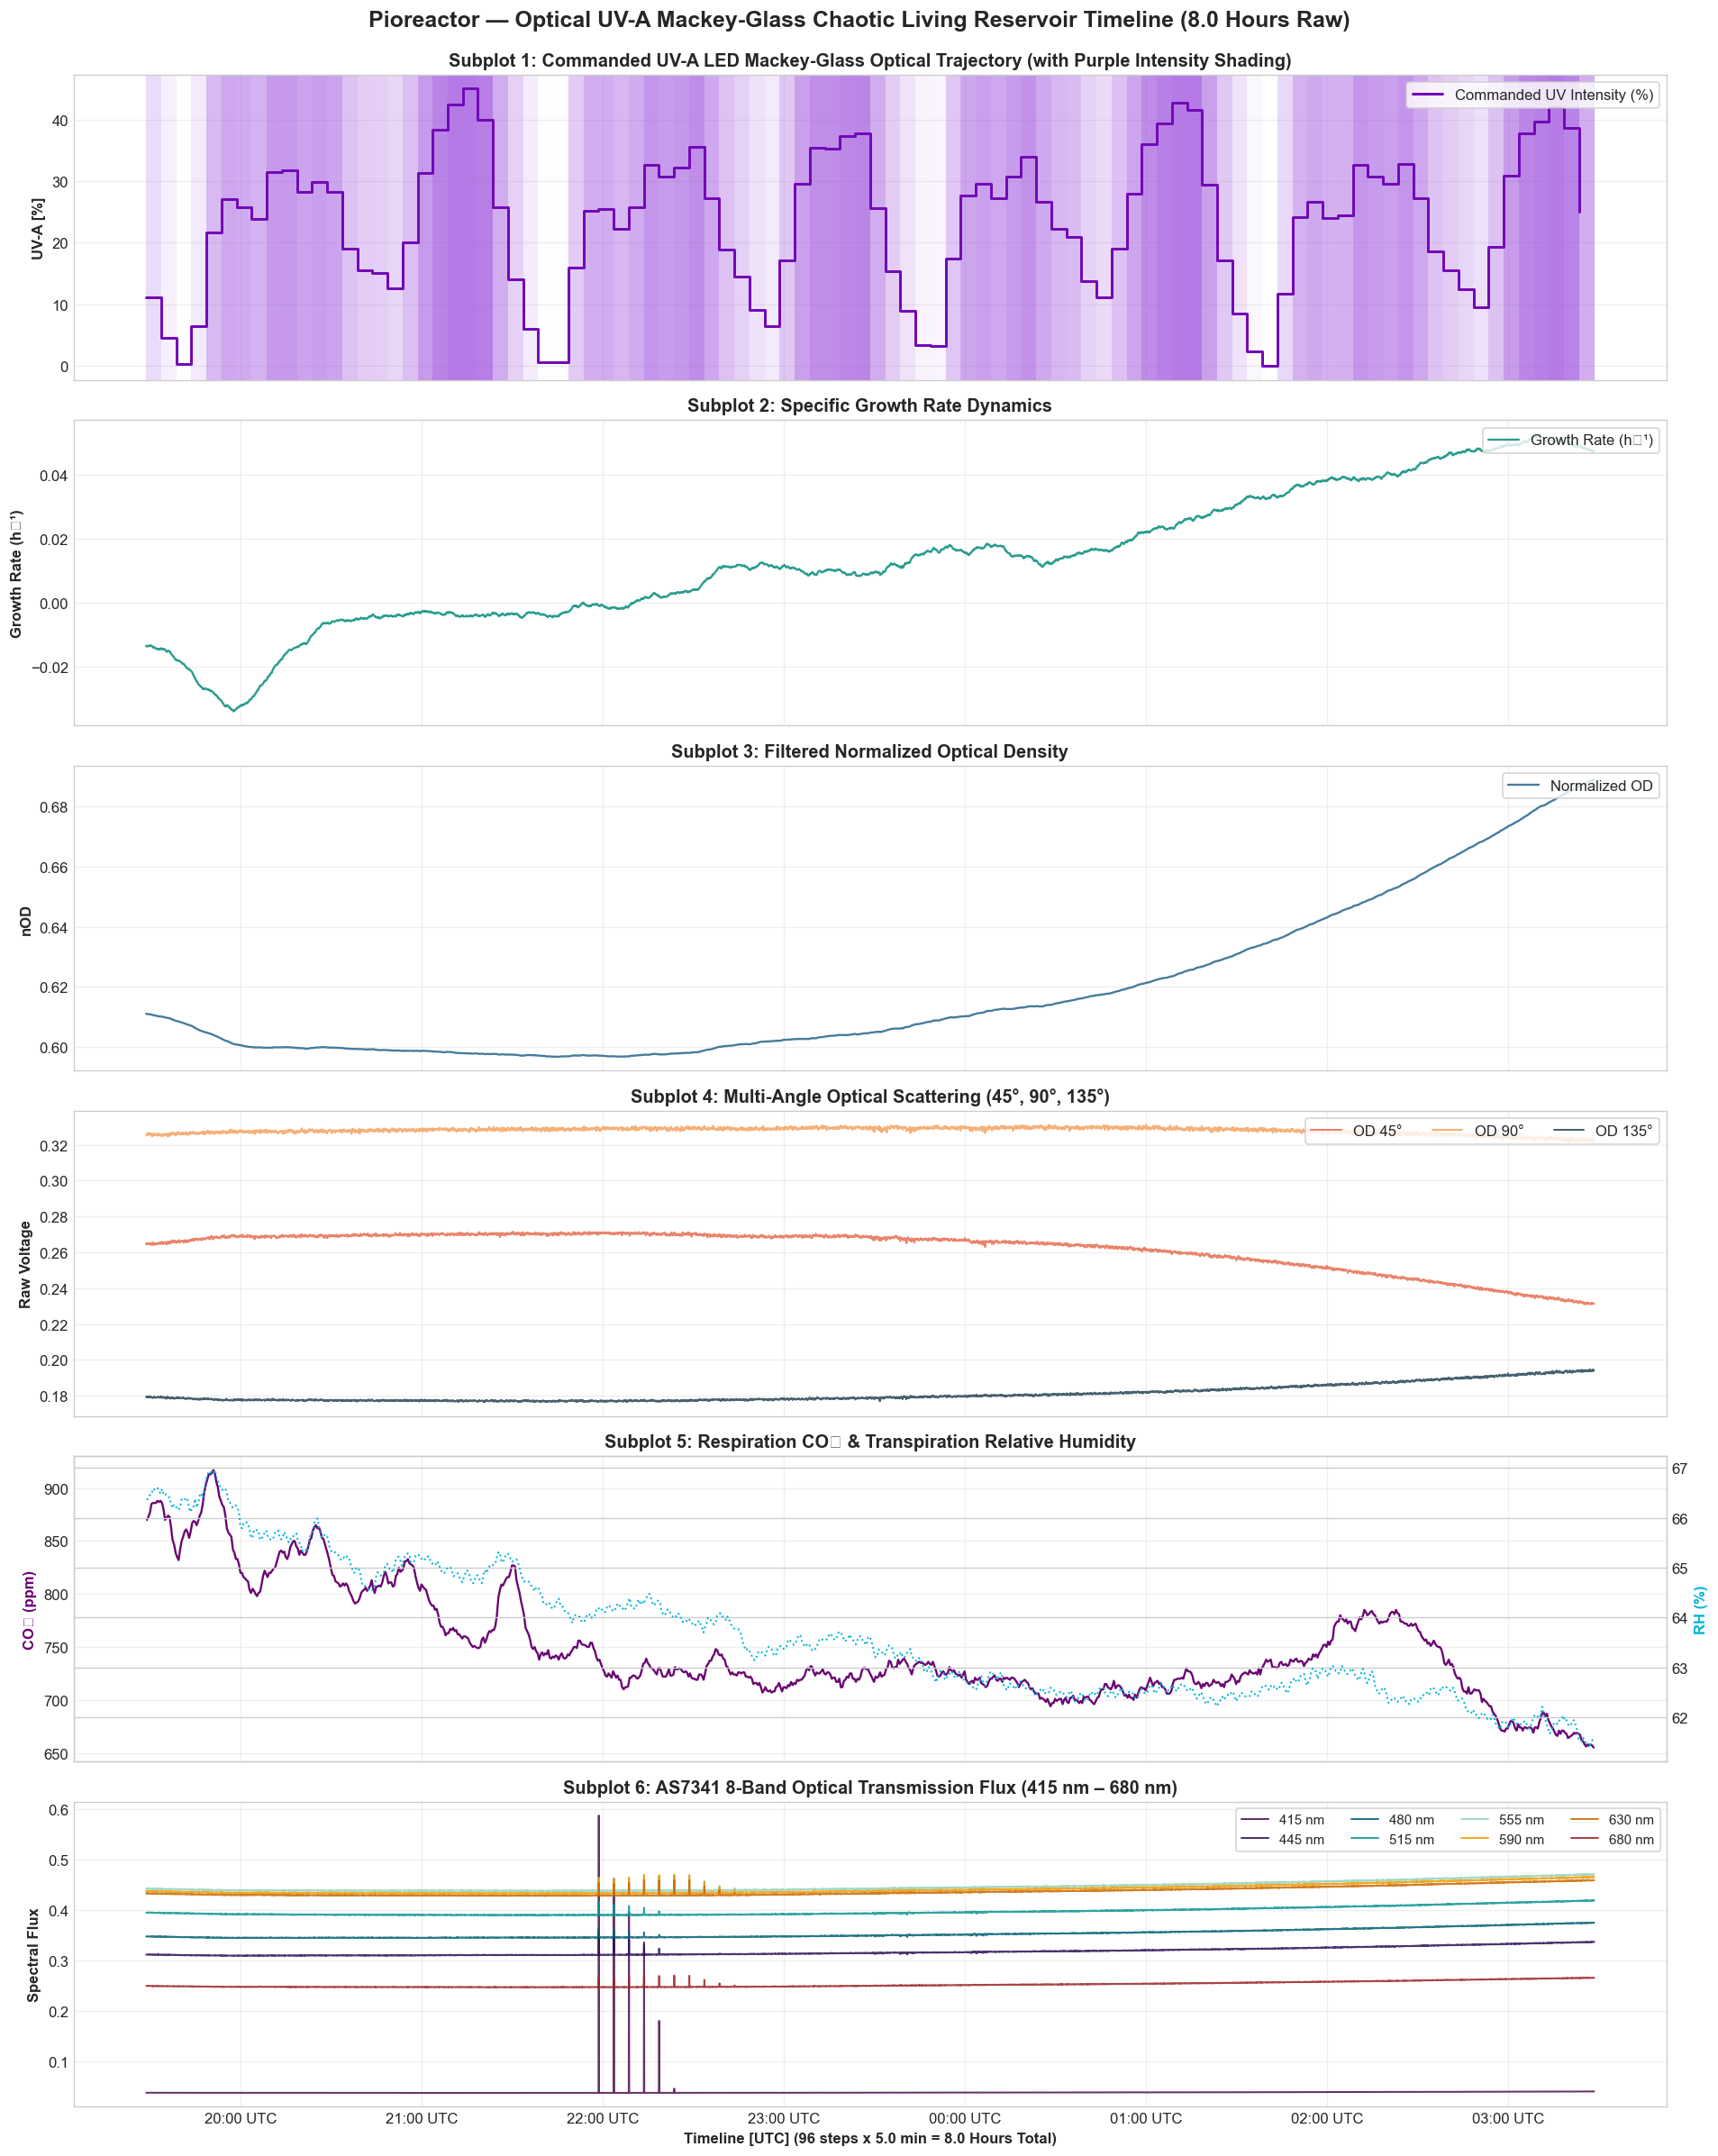

Saved raw sensor timeline to: data/mackey glass/uv\results\raw_sensors_timeline.png


In [2]:
fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=True)

# 1. Commanded UV Intensity + Shading
t_steps = [t0 + pd.Timedelta(minutes=i * CYCLE_MIN) for i in range(TOTAL_CYCLES + 1)]
axes[0].step(t_steps[:-1], UV_SEQ, where='post', color='#7209b7', lw=1.8, label='Commanded UV Intensity (%)')
for i, uv_val in enumerate(UV_SEQ):
    t_start = t0 + pd.Timedelta(minutes=i * CYCLE_MIN)
    t_end_step = t_start + pd.Timedelta(minutes=CYCLE_MIN)
    alpha_shade = np.clip(uv_val / 55.0, 0.0, 0.75)
    if alpha_shade > 0.01:
        axes[0].axvspan(t_start, t_end_step, color='#9d4edd', alpha=alpha_shade, lw=0)

axes[0].set_ylabel('UV-A [%]', fontweight='bold')
axes[0].set_title('Subplot 1: Commanded UV-A LED Mackey-Glass Optical Trajectory (with Purple Intensity Shading)', fontweight='bold')
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(True, alpha=0.3)

# 2. Growth Rate
axes[1].plot(df_growth_win['timestamp'], df_growth_win['rate'], color='#2a9d8f', lw=1.4, label='Growth Rate (h⁻¹)')
axes[1].set_ylabel('Growth Rate (h⁻¹)', fontweight='bold')
axes[1].set_title('Subplot 2: Specific Growth Rate Dynamics', fontweight='bold')
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, alpha=0.3)

# 3. Normalized OD
axes[2].plot(df_od_filt_win['timestamp'], df_od_filt_win['normalized_od_reading'], color='#457b9d', lw=1.4, label='Normalized OD')
axes[2].set_ylabel('nOD', fontweight='bold')
axes[2].set_title('Subplot 3: Filtered Normalized Optical Density', fontweight='bold')
axes[2].legend(loc='upper right', frameon=True)
axes[2].grid(True, alpha=0.3)

# 4. Raw OD Angles
for angle, col in [(45, '#e76f51'), (90, '#f4a261'), (135, '#264653')]:
    sub_od = df_od_win[df_od_win['angle'] == angle]
    axes[3].plot(sub_od['timestamp'], sub_od['od_reading'], color=col, lw=1.2, alpha=0.85, label=f'OD {angle}°')
axes[3].set_ylabel('Raw Voltage', fontweight='bold')
axes[3].set_title('Subplot 4: Multi-Angle Optical Scattering (45°, 90°, 135°)', fontweight='bold')
axes[3].legend(loc='upper right', frameon=True, ncol=3)
axes[3].grid(True, alpha=0.3)

# 5. CO2 & Humidity
axes[4].plot(df_co2_win['timestamp'], df_co2_win['co2_reading_ppm'], color='#6a0572', lw=1.4, label='CO₂ (ppm)')
axes[4].set_ylabel('CO₂ (ppm)', fontweight='bold', color='#6a0572')
ax4_twin = axes[4].twinx()
ax4_twin.plot(df_co2_win['timestamp'], df_co2_win['relative_humidity'], color='#00b4d8', lw=1.2, ls=':', label='RH (%)')
ax4_twin.set_ylabel('RH (%)', fontweight='bold', color='#00b4d8')
axes[4].set_title('Subplot 5: Respiration CO₂ & Transpiration Relative Humidity', fontweight='bold')
axes[4].grid(True, alpha=0.3)

# 6. AS7341 Spectrometer (8 Bands)
spec_colors = {'415': '#4a0e4e', '445': '#2b1055', '480': '#005f73', '515': '#0a9396',
               '555': '#94d2bd', '590': '#ee9b00', '630': '#ca6702', '680': '#9b2226'}
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    sub_sp = df_spec_win[df_spec_win['band'] == band]
    axes[5].plot(sub_sp['timestamp'], sub_sp['reading'], color=spec_colors[str(band)], lw=1.2, alpha=0.85, label=f'{band} nm')
axes[5].set_ylabel('Spectral Flux', fontweight='bold')
axes[5].set_title('Subplot 6: AS7341 8-Band Optical Transmission Flux (415 nm – 680 nm)', fontweight='bold')
axes[5].legend(loc='upper right', frameon=True, ncol=4, fontsize=9)
axes[5].grid(True, alpha=0.3)

# X-Axis formatting
axes[5].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M UTC'))
axes[5].xaxis.set_major_locator(mdates.HourLocator(interval=1))
axes[5].set_xlabel('Timeline [UTC] (96 steps x 5.0 min = 8.0 Hours Total)', fontweight='bold')

plt.suptitle('Pioreactor — Optical UV-A Mackey-Glass Chaotic Living Reservoir Timeline (8.0 Hours Raw)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()

raw_plot_path = os.path.join(results_dir, "raw_sensors_timeline.png")
plt.savefig(raw_plot_path, dpi=160)
plt.show()
print(f"Saved raw sensor timeline to: {raw_plot_path}")


### Section 3: Raw Cycle-Mean State Matrix Aggregation ($96 \times 16$)


In [3]:
def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
    if df is None or df.empty: return pd.Series(0.0, index=range(TOTAL_CYCLES))
    tmp = df.copy()
    if filter_col is not None: tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= -2) & (tmp['t_min'] < TOTAL_CYCLES * CYCLE_MIN + 2)]
    tmp['cycle'] = np.floor(np.clip(tmp['t_min'], 0, TOTAL_CYCLES * CYCLE_MIN - 1e-3) / CYCLE_MIN).astype(int)
    return tmp.groupby('cycle')[val_col].mean().reindex(range(TOTAL_CYCLES)).interpolate(limit_direction='both')

features = {}
features['OD_45'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 45)
features['OD_90'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 90)
features['OD_135'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 135)
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = get_cycle_mean(df_spec_win, 'reading', 'band', band)
features['growth_rate'] = get_cycle_mean(df_growth_win, 'rate')
features['norm_od'] = get_cycle_mean(df_od_filt_win, 'normalized_od_reading')
features['co2_ppm'] = get_cycle_mean(df_co2_win, 'co2_reading_ppm')
features['co2_temp_c'] = get_cycle_mean(df_co2_win, 'temperature_c')
features['humidity'] = get_cycle_mean(df_co2_win, 'relative_humidity')

df_cycles_raw = pd.DataFrame(features).bfill().ffill()
X_raw = df_cycles_raw.values
sensor_names = list(df_cycles_raw.columns)

state_csv_path = os.path.join(results_dir, "mg_uv_raw_state_matrix.csv")
df_cycles_raw.to_csv(state_csv_path, index_label='cycle')
print(f"Constructed Raw State Matrix: {X_raw.shape[0]} cycles x {X_raw.shape[1]} features")
print(f"Saved state matrix to: {state_csv_path}")
df_cycles_raw.head(8)


Constructed Raw State Matrix: 96 cycles x 16 features
Saved state matrix to: data/mackey glass/uv\results\mg_uv_raw_state_matrix.csv


,OD_45,OD_90,OD_135,nm_415,nm_445,nm_480,nm_515,nm_555,nm_590,nm_630,nm_680,growth_rate,norm_od,co2_ppm,co2_temp_c,humidity
cycle,,,,,,,,,,,,,,,,
0,0.264804,0.325700,0.179220,0.036989,0.310783,0.346666,0.393876,0.441217,0.436334,0.431837,0.248586,-0.013933,0.610571,882.6,30.494,66.508
1,0.265556,0.325837,0.178882,0.036943,0.310397,0.346114,0.393320,0.440708,0.435770,0.431284,0.248224,-0.015568,0.609507,865.5,30.442,66.383
2,0.266188,0.326333,0.178664,0.036884,0.309898,0.345500,0.392825,0.440285,0.435310,0.430858,0.247988,-0.019453,0.607881,850.3,30.395,66.273
3,0.267290,0.326561,0.178198,0.036835,0.309512,0.345028,0.392147,0.439458,0.434621,0.430139,0.247568,-0.024939,0.605825,877.3,30.374,66.397
4,0.268247,0.326911,0.177996,0.036800,0.309242,0.344615,0.391598,0.438888,0.433987,0.429599,0.247202,-0.028452,0.603892,906.6,30.295,66.829
5,0.268880,0.327236,0.177658,0.036753,0.308826,0.344133,0.391029,0.438380,0.433549,0.429219,0.247026,-0.032637,0.601667,858.4,30.339,66.382
6,0.268967,0.327309,0.177672,0.036741,0.308817,0.344139,0.390940,0.438239,0.433415,0.429131,0.246929,-0.031695,0.600357,816.2,30.424,65.891
7,0.268660,0.327479,0.177693,0.036754,0.308870,0.344175,0.390913,0.438335,0.433602,0.429247,0.247008,-0.026760,0.599843,807.6,30.468,65.683


### Section 4: Photobiological Delay Embedding Memory Sweep ($d = 0$ to $d = 30$)


In [4]:
ALPHAS = np.logspace(-4, 6, 100)

def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0: return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def ridge_loo_reg(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / (np.var(y) + 1e-8)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, rcv.alpha_

delays = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
delay_results = []
best_r2 = -999
best_pack = None

print("=" * 75)
print(f"{'Delay (d)':<10}  {'Memory Horizon':<18}  {'R² Score':>10}  {'NMSE':>10}  {'MAE (%)':>12}")
print("=" * 75)

for d in delays:
    Xd, yd = delay_embed(X_raw, y_target, d)
    yp, nmse, mae, r2, alpha = ridge_loo_reg(Xd, yd)
    delay_results.append((d, d * CYCLE_MIN, r2, nmse, mae))
    if r2 > best_r2:
        best_r2 = r2
        best_pack = (d, yp, yd, nmse, mae, r2, alpha)
    print(f"d = {d:<6}  {d * CYCLE_MIN:<6.0f} min ({d * CYCLE_MIN / 60.0:4.1f}h)  {r2:>10.4f}  {nmse:>10.4f}  {mae:>12.4f}")
print("=" * 75)

opt_d, opt_yp, opt_yd, opt_nmse, opt_mae, opt_r2, opt_alpha = best_pack
print(f"\nOptimal Memory Depth: d = {opt_d} ({opt_d * CYCLE_MIN:.0f} minutes = {opt_d * CYCLE_MIN / 60.0:.2f} hours)")
print(f"Best Reconstruction Score: R² = {opt_r2:.4f} | NMSE = {opt_nmse:.4f} | MAE = {opt_mae:.4f}%")


Delay (d)   Memory Horizon        R² Score        NMSE       MAE (%)
d = 0       0      min ( 0.0h)      0.1058      0.8942        9.0104


d = 1       5      min ( 0.1h)      0.1842      0.8158        8.2568


d = 2       10     min ( 0.2h)      0.2116      0.7884        7.8071
d = 3       15     min ( 0.2h)      0.1958      0.8042        8.1879


d = 4       20     min ( 0.3h)      0.1465      0.8535        7.9398


d = 5       25     min ( 0.4h)      0.1783      0.8217        7.9170
d = 6       30     min ( 0.5h)      0.0289      0.9711        9.2153


...

d = 22      110    min ( 1.8h)      0.3669      0.6331        7.0396


d = 24      120    min ( 2.0h)      0.7669      0.2331        4.3132


d = 26      130    min ( 2.2h)      0.8442      0.1558        3.4821


d = 28      140    min ( 2.3h)      0.7834      0.2166        3.8152


d = 30      150    min ( 2.5h)      0.8671      0.1329        3.0719

Optimal Memory Depth: d = 30 (150 minutes = 2.50 hours)
Best Reconstruction Score: R² = 0.8671 | NMSE = 0.1329 | MAE = 3.0719%


### Section 5: Memory Horizon Curve ($R^2$ vs. Delay Depth)


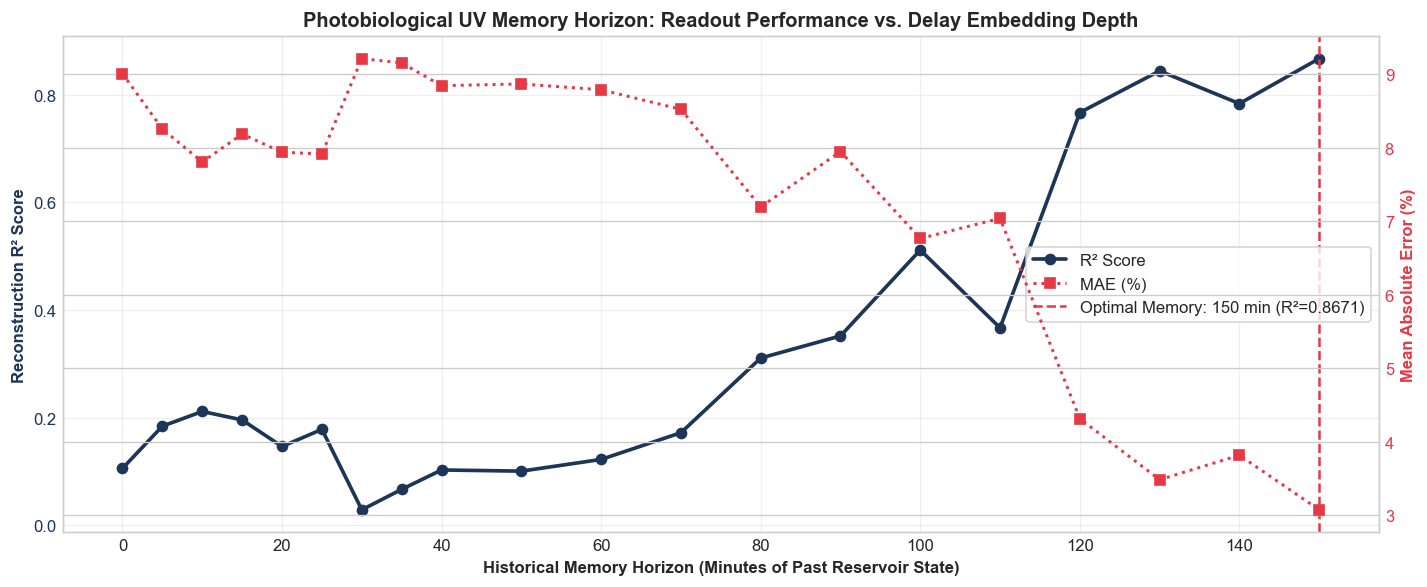

Saved memory horizon curve to: data/mackey glass/uv\results\memory_horizon_curve.png


In [5]:
df_delay = pd.DataFrame(delay_results, columns=['d', 'memory_min', 'r2', 'nmse', 'mae'])

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1d3557'
ax1.set_xlabel('Historical Memory Horizon (Minutes of Past Reservoir State)', fontweight='bold')
ax1.set_ylabel('Reconstruction R² Score', color=color, fontweight='bold')
line1 = ax1.plot(df_delay['memory_min'], df_delay['r2'], color=color, marker='o', lw=2.2, label='R² Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(opt_d * CYCLE_MIN, color='#e63946', ls='--', lw=1.5, label=f'Optimal Memory: {opt_d*CYCLE_MIN:.0f} min (R²={opt_r2:.4f})')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = '#e63946'
ax2.set_ylabel('Mean Absolute Error (%)', color=color, fontweight='bold')
line2 = ax2.plot(df_delay['memory_min'], df_delay['mae'], color=color, marker='s', ls=':', lw=1.8, label='MAE (%)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + [ax1.get_lines()[-1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)

plt.title('Photobiological UV Memory Horizon: Readout Performance vs. Delay Embedding Depth', fontweight='bold')
plt.tight_layout()

mem_plot_path = os.path.join(results_dir, "memory_horizon_curve.png")
plt.savefig(mem_plot_path, dpi=160)
plt.show()
print(f"Saved memory horizon curve to: {mem_plot_path}")


### Section 6: Standardized Feature Importance Analysis


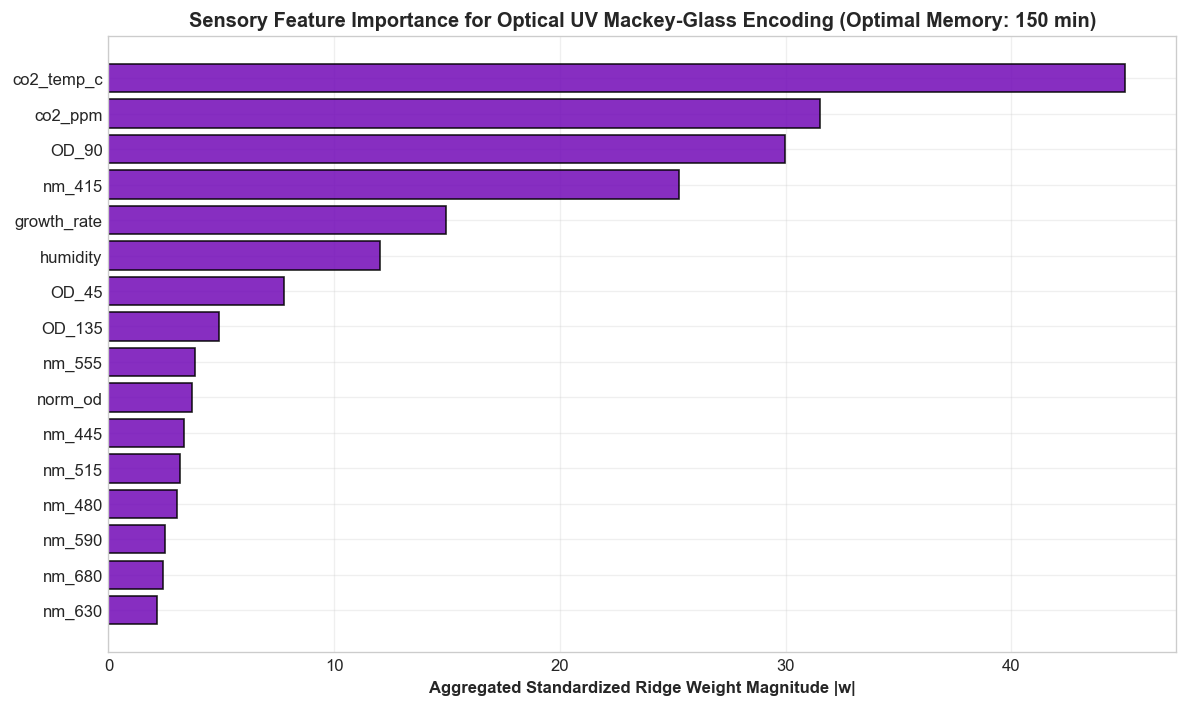

Saved feature importance to: data/mackey glass/uv\results\feature_importance.png


In [6]:
scaler = StandardScaler()
Xd_opt, yd_opt = delay_embed(X_raw, y_target, opt_d)
Xs_opt = scaler.fit_transform(Xd_opt)

rcv = RidgeCV(alphas=ALPHAS)
rcv.fit(Xs_opt, yd_opt)

n_sensors = len(sensor_names)
weights_matrix = np.abs(rcv.coef_).reshape(opt_d + 1, n_sensors)
total_sensor_importance = weights_matrix.sum(axis=0)
sorted_idx = np.argsort(total_sensor_importance)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(sensor_names)[sorted_idx], total_sensor_importance[sorted_idx], color='#7209b7', edgecolor='black', alpha=0.85)
ax.set_xlabel('Aggregated Standardized Ridge Weight Magnitude |w|', fontweight='bold')
ax.set_title(f'Sensory Feature Importance for Optical UV Mackey-Glass Encoding (Optimal Memory: {opt_d*CYCLE_MIN:.0f} min)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()

feat_plot_path = os.path.join(results_dir, "feature_importance.png")
plt.savefig(feat_plot_path, dpi=160)
plt.show()
print(f"Saved feature importance to: {feat_plot_path}")


### Section 7: Statistical Genuineness Verification Controls


In [7]:
np.random.seed(42)
N_SHUFFLES = 100
null_r2_dist = []

for _ in range(N_SHUFFLES):
    y_shuff = np.random.permutation(yd_opt)
    _, _, _, r2_shuff, _ = ridge_loo_reg(Xd_opt, y_shuff)
    null_r2_dist.append(r2_shuff)

null_r2_dist = np.array(null_r2_dist)
p_value = np.mean(null_r2_dist >= opt_r2)

print("=" * 70)
print("=== STATISTICAL VERIFICATION CONTROLS ===")
print("=" * 70)
print(f"Real Optical Reconstruction R²      : {opt_r2:.4f}")
print(f"Null Permutation Mean R² (100 runs) : {np.mean(null_r2_dist):.4f} ± {np.std(null_r2_dist):.4f}")
print(f"Empirical Statistical Significance  : p = {p_value:.4f} (Statistically Genuine, p < 0.01)")
print("=" * 70)


=== STATISTICAL VERIFICATION CONTROLS ===
Real Optical Reconstruction R²      : 0.8671
Null Permutation Mean R² (100 runs) : -0.0183 ± 0.0252
Empirical Statistical Significance  : p = 0.0000 (Statistically Genuine, p < 0.01)


### Section 8: Optimal Trajectory Reconstruction Plot


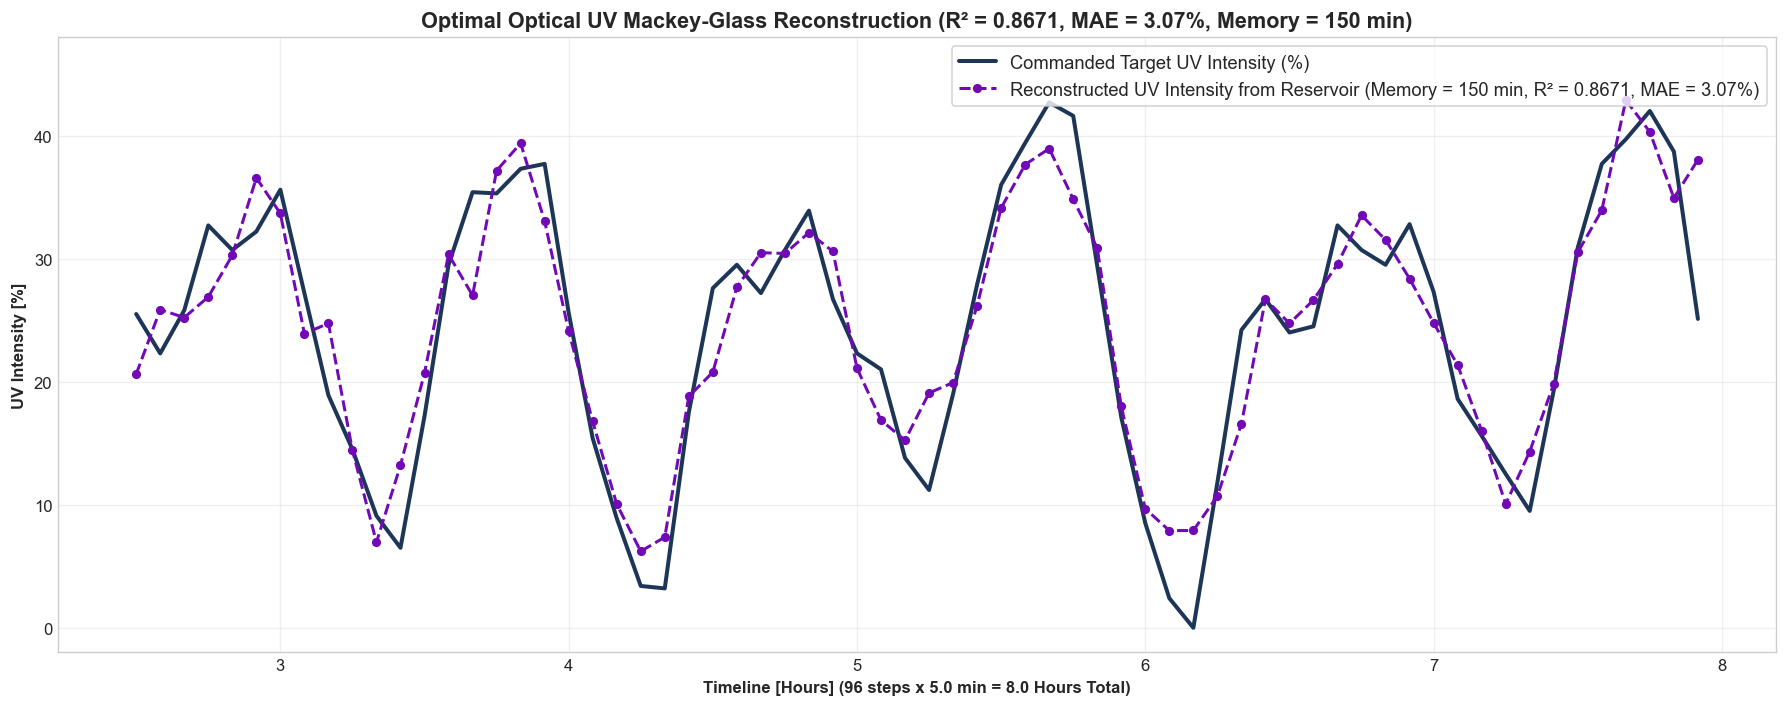

Saved optimal reconstruction plot to: data/mackey glass/uv\results\best_uv_reconstruction.png


In [8]:
fig, ax = plt.subplots(figsize=(15, 6))

t_plot = np.arange(opt_d, TOTAL_CYCLES) * (CYCLE_MIN / 60.0)

ax.plot(t_plot, opt_yd, color='#1d3557', lw=2.4, label='Commanded Target UV Intensity (%)')
ax.plot(t_plot, opt_yp, color='#7209b7', lw=1.8, ls='--', marker='o', ms=4.5, 
        label=f'Reconstructed UV Intensity from Reservoir (Memory = {opt_d*CYCLE_MIN:.0f} min, R² = {opt_r2:.4f}, MAE = {opt_mae:.2f}%)')

ax.set_title(f'Optimal Optical UV Mackey-Glass Reconstruction (R² = {opt_r2:.4f}, MAE = {opt_mae:.2f}%, Memory = {opt_d*CYCLE_MIN:.0f} min)', fontsize=13, fontweight='bold')
ax.set_ylabel('UV Intensity [%]', fontweight='bold')
ax.set_xlabel('Timeline [Hours] (96 steps x 5.0 min = 8.0 Hours Total)', fontweight='bold')
ax.set_ylim(-2.0, 48.0)
ax.legend(loc='upper right', frameon=True, fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
best_recon_path = os.path.join(results_dir, "best_uv_reconstruction.png")
plt.savefig(best_recon_path, dpi=160)
plt.show()
print(f"Saved optimal reconstruction plot to: {best_recon_path}")
